### **Description**

This recipe shows how to calculate the volume census in discrete temperature-salinity coordinates using annual-mean outputs from the National Oceanography Centre Near-Present-Day global eORCA1 configuration of NEMO forced using JRA55-do from 1976-2024.

For more details on this model configuration and the available outputs, users can explore the Near-Present-Day documentation [here](https://noc-msm.github.io/NOC_Near_Present_Day/).

---

In [1]:
# -- Import required packages -- #
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from nemo_cookbook import NEMODataTree

xr.set_options(display_style="text")

### **Using Dask**

**Optional: Connect Client to Dask Local Cluster to run analysis in parallel.**

**Note:** Although using Dask is not strictly necessary for this simple example using eORCA1, if we wanted to generalise this recipe to eORCA025 or eORCA12 outputs, using Dask would be essential to avoid unnecessary slow calculations using only a single process.

In [ ]:
# -- Initialise Dask Local Cluster -- #
import os

import dask
from dask.distributed import Client, LocalCluster

# Update temporary directory for Dask workers:
dask.config.set({'temporary_directory': f"{os.getcwd()}/dask_tmp",
                 'local_directory': f"{os.getcwd()}/dask_tmp"
                 })

# Create Local Cluster:
cluster = LocalCluster(n_workers=4, threads_per_worker=3, memory_limit='5GB')
client = Client(cluster)
client

### **Accessing NEMO Model Data**
**Let's begin by loading the grid variables for our eORCA1 NEMO model from the [JASMIN Object Store](https://help.jasmin.ac.uk/docs/short-term-project-storage/using-the-jasmin-object-store/)**. 

**Alternatively, you can replace the ``domain_filepath`` below with a file path to your domain_cfg.nc file and read this with xarray's ``open_dataset()`` function.**

In [3]:
# Define directory path to ancillary files:
domain_filepath = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/domain_cfg"

# Open eORCA1 NEMO model domain_cfg:
ds_domain = xr.open_zarr(domain_filepath, consolidated=True, chunks={})

ds_domain

<xarray.Dataset> Size: 709MB
Dimensions:       (y: 331, x: 360, nav_lev: 75)
Coordinates:
  * nav_lev       (nav_lev) int64 600B 0 1 2 3 4 5 6 7 ... 68 69 70 71 72 73 74
  * x             (x) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * y             (y) int64 3kB 0 1 2 3 4 5 6 7 ... 324 325 326 327 328 329 330
Data variables: (12/49)
    atlmsk        (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    bathy_metry   (y, x) float32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    bottom_level  (y, x) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1f           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1t           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1u           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    ...            ...
    top_level     (y, x) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    umask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    umaskutil     (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    vmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    vmaskutil     (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    wmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
Attributes:
    CfgName:    UNKNOWN
    CfgIndex:   -999
    Iperio:     1
    Jperio:     0
    NFold:      1
    NFtype:     F
    VertCoord:  zps
    IsfCav:     0
    file_name:  mesh_mask.nc
    TimeStamp:  01/03/2025 22:19:49 -0000

**Next, we need to import the sea water conservative temperature and absolute salinity stored at T-points in a single dataset.**

In [4]:
# Define directory path to model output files:
gridT_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/T1y"

# Construct NEMO model T-grid dataset, including conservative temperature (degC):
ds_gridT = xr.open_zarr(gridT_url, consolidated=True, chunks={})

ds_gridT

<xarray.Dataset> Size: 39GB
Dimensions:                (time_counter: 48, y: 331, x: 360, deptht: 75,
                            axis_nbounds: 2)
Coordinates:
  * deptht                 (deptht) float32 300B 0.5058 1.556 ... 5.902e+03
    nav_lat                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lon                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    time_centered          (time_counter) datetime64[ns] 384B dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter           (time_counter) datetime64[ns] 384B 1976-07-02 ... ...
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/74)
    berg_latent_heat_flux  (time_counter, y, x) float32 23MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    deptht_bounds          (deptht, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
    e3t                    (time_counter, deptht, y, x) float32 2GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    empmr                  (time_counter, y, x) float32 23MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    evs                    (time_counter, y, x) float32 23MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ficeberg               (time_counter, y, x) float32 23MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ...                     ...
    ttrd_qns_li            (time_counter, y, x) float32 23MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    vohfcisf               (time_counter, deptht, y, x) float32 2GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vohflisf               (time_counter, deptht, y, x) float32 2GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vowflisf               (time_counter, deptht, y, x) float32 2GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    zos                    (time_counter, y, x) float32 23MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    zossq                  (time_counter, y, x) float32 23MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA1_1y_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2024-Dec-09 10:28:01 GMT
    uuid:         89824b34-5d44-4531-8344-fe1ce39fbb7b

### **Creating a NEMODataTree**

**Next, let's create a NEMODataTree to store our domain and T- & V-grid variables for the eORCA1 model.**

In [5]:
# Define dictionary of grid datasets defining eORCA1 parent model domain with no child/grand-child nests:
datasets = {"parent": {"domain": ds_domain, "gridT": ds_gridT}}

# Initialise a new NEMODataTree whose parent domain is zonally periodic & north-folding on F-points:
nemo = NEMODataTree.from_datasets(datasets=datasets, iperio=True, nftype="F", read_mask=True)

nemo

<xarray.DataTree 'NEMO model'>
Group: /
│   Dimensions:               (time_counter: 48, axis_nbounds: 2)
│   Coordinates:
│       time_centered         (time_counter) datetime64[ns] 384B dask.array<chunksize=(1,), meta=np.ndarray>
│     * time_counter          (time_counter) datetime64[ns] 384B 1976-07-02 ... 2...
│   Dimensions without coordinates: axis_nbounds
│   Data variables:
│       time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 768B dask.array<chunksize=(1, 2), meta=np.ndarray>
│       time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 768B dask.array<chunksize=(1, 2), meta=np.ndarray>
│   Attributes:
│       nftype:   F
│       iperio:   True
├── Group: /gridT
│       Dimensions:                (time_counter: 48, j: 331, i: 360, k: 75,
│                                   axis_nbounds: 2)
│       Coordinates:
│         * deptht                 (k) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
│           time_centered          (time_counter) datetime64[ns] 384B dask.array<chunksize=(1,), meta=np.ndarray>
│           gphit                  (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           glamt                  (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│         * k                      (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
│         * j                      (j) int64 3kB 1 2 3 4 5 6 ... 326 327 328 329 330 331
│         * i                      (i) int64 3kB 1 2 3 4 5 6 ... 355 356 357 358 359 360
│       Dimensions without coordinates: axis_nbounds
│       Data variables: (12/80)
│           berg_latent_heat_flux  (time_counter, j, i) float32 23MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           deptht_bounds          (k, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
│           e3t                    (time_counter, k, j, i) float32 2GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
│           empmr                  (time_counter, j, i) float32 23MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           evs                    (time_counter, j, i) float32 23MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           ficeberg               (time_counter, j, i) float32 23MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           ...                     ...
│           e1t                    (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           e2t                    (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           top_level              (j, i) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           bottom_level           (j, i) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           tmask                  (k, j, i) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
│           tmaskutil              (j, i) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│       Attributes:
│           nftype:   F
│           iperio:   True
├── Group: /gridU
│       Dimensions:       (j: 331, i: 360, k: 75)
│       Coordinates:
│           gphiu         (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           glamu         (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│         * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 325 326 327 328 329 330 331
│         * i             (i) float64 3kB 1.5 2.5 3.5 4.5 ... 357.5 358.5 359.5 360.5
│       Data variables:
│           e1u           (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           e2u           (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           umask         (k, j, i) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
│           umaskutil     (j, i) int8

### **Calculating Volume Census**

**Now we have constructed our `NEMODataTree`, let's calculate the volume census in in T-S coordinates using the `.binned_statistic()` method:**

In [6]:
# Define Atlantic Ocean basin mask:
atlmask = ds_domain['atlmsk'].rename({"x":"i", "y":"j"}).astype(bool)

In [7]:
# Define discrete conservative temperature [C] and absolute salinity [g/kg] bins:
thetao_bins = np.arange(-2, 35, 0.5)
so_bins = np.arange(20, 38, 0.1)

# Compute volume of each T-grid cell [m3].
nemo['gridT']['volcello'] = nemo.cell_volume(grid='gridT')

# Compute total volume in discrete conservative temperature - absolute salinity coords:
vol_thetao_so_atl = nemo.binned_statistic(grid="gridT",
                                          vars=["thetao_con", "so_abs"],
                                          values="volcello",
                                          keep_dims=["time_counter"],
                                          bins=[thetao_bins, so_bins],
                                          statistic="nansum",
                                          mask=atlmask
                                          )

vol_thetao_so_atl

<xarray.DataArray 'volcello' (time_counter: 48, thetao_con_bins: 73,
                              so_abs_bins: 179)> Size: 5MB
dask.array<reshape, shape=(48, 73, 179), dtype=float64, chunksize=(48, 73, 179), chunktype=numpy.ndarray>
Coordinates:
  * time_counter     (time_counter) datetime64[ns] 384B 1976-07-02 ... 2023-0...
  * thetao_con_bins  (thetao_con_bins) float64 584B -1.75 -1.25 ... 33.75 34.25
  * so_abs_bins      (so_abs_bins) float64 1kB 20.05 20.15 20.25 ... 37.75 37.85

**Notice that the output above contains dask arrays, so we haven't actually computed the volume census yet. To do this, we need to call the ``.compute()`` method:**

In [8]:
vol_thetao_so_atl = vol_thetao_so_atl.compute()

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


### **Visualising the time-mean volume census in T-S coordinates**

**Finally, let's visualise the results by plotting the time-mean volume census in conservative temperature - absolute salinity space using a logarithmic scale:**

Text(0, 0.5, 'Conservative Temperature [$^{\\circ}$C]')

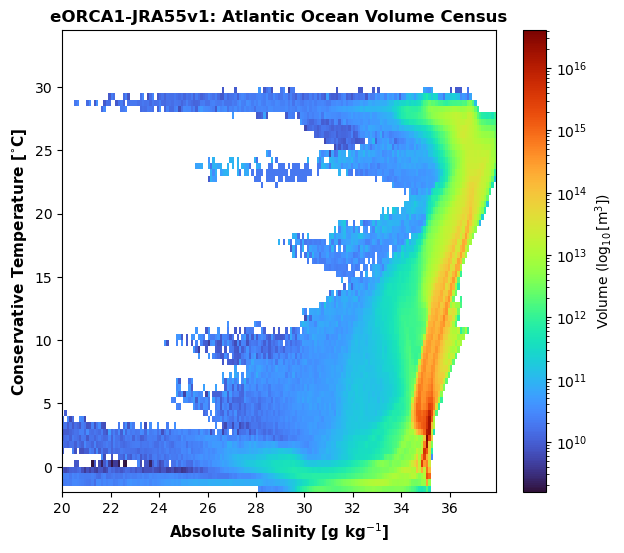

In [12]:
# -- Plot time-mean volume census in conservative temperature - absolute salinity space -- #
plt.figure(figsize=(7, 6))

# Calculate time-mean volume census:
plt_data = vol_thetao_so_atl.mean(dim='time_counter')

# Plot time-mean volume census:
(plt_data
 .plot(norm=colors.LogNorm(vmin=plt_data.min(),
                           vmax=plt_data.max()),
                           cmap="turbo",
                           cbar_kwargs={"label": "Volume ($\\log_{10}$[m$^3$])"}
                           )
 )

# Axes labels:
plt.title('eORCA1-JRA55v1: Atlantic Ocean Volume Census', fontdict={'size':12, 'weight':'bold'})
plt.xlabel('Absolute Salinity [g kg$^{-1}$]', fontdict={'size':11, 'weight':'bold'})
plt.ylabel('Conservative Temperature [$^{\\circ}$C]', fontdict={'size':11, 'weight':'bold'})